Импорт библиотек

In [3]:
import numpy as np
import matplotlib.pyplot as plt

***Задание 3***

Функции для красоты вывода

In [4]:
MATCH    =  3
MISMATCH = -3
GAP = -2
def print_alignment(align_X, align_Y, final_score):
    """Вывод выравнивания"""
    # Строка совпадений
    match_line = ''
    for a, b in zip(align_X, align_Y):
        if a == b:
            match_line += '|'  # match
        elif a == '-' or b == '-':
            match_line += ' '  # gap
        else:
            match_line += 'x'  # mismatch
    print(f"\nИтоговое выравнивание (Score = {final_score}):")
    print(f"  X: {align_X}")
    print(f"     {match_line}")
    print(f"  Y: {align_Y}")

def print_matrix(F, X, Y):
    """Вывод матрицы"""
    header = '     ' + '   ' + '   '.join(list(Y))
    print(header)
    print('   ' + '-' * (len(Y)*4 + 5))
    
    for i in range(len(X)+1):
        label = ' ' if i == 0 else X[i-1]
        row = f' {label} | '
        for j in range(len(Y)+1):
            row += f'{F[i][j]:3d} '
        print(row)
def score(a, b):
    """Возвращает Match или Mismatch в зависимости от символов"""
    return MATCH if a == b else MISMATCH


Функции реализующие Алгоритм Нидлмана-Вунша с линейным штрафом и афинным штрафом за гэпы.

In [5]:
NEG_INF = -10**5

def needleman_wunsch_linear(X, Y, gap=-4):
    """
    Алгоритм Нидлмана-Вунша с линейным штрафом за гэп.
    """
    n, m = len(X), len(Y)
    F = np.zeros((n+1, m+1), dtype=int)   #матрица для хранения оптимальных значений
    trace = np.full((n+1, m+1), '', dtype=object)    #матрица для обратного хода
    
    for i in range(n+1):
        F[i][0] = i * gap
        trace[i][0] = 'U'   # 'U' — пришли сверху
    for j in range(m+1):
        F[0][j] = j * gap
        trace[0][j] = 'L'   # 'L' — пришли слева
    trace[0][0] = 'S'   # 'S' — стартовая позиция
    
    for i in range(1, n+1):
        for j in range(1, m+1):
            diag = F[i-1][j-1] + score(X[i-1], Y[j-1])
            up   = F[i-1][j]   + gap
            left = F[i][j-1]   + gap
            F[i][j] = max(diag, up, left)
            if F[i][j] == diag:
                trace[i][j] = 'D'   # 'D' — пришли по диагонали
            elif F[i][j] == up:
                trace[i][j] = 'U'
            else:
                trace[i][j] = 'L'
    
    # Traceback
    align_X, align_Y = '', ''
    i, j = n, m
    while i > 0 or j > 0:
        if trace[i][j] == 'D':
            align_X = X[i-1] + align_X
            align_Y = Y[j-1] + align_Y
            i -= 1; j -= 1
        elif trace[i][j] == 'U':
            align_X = X[i-1] + align_X
            align_Y = '-'    + align_Y
            i -= 1
        else:
            align_X = '-'    + align_X
            align_Y = Y[j-1] + align_Y
            j -= 1
    
    return F, align_X, align_Y, F[n][m]


def needleman_wunsch_affine(X, Y, gap_open=-10, gap_extend=-1):
    """
    Алгоритм Нидлмана-Вунша с афинным штрафом за гэпы
    gap_open   — штраф за открытие нового гэпа
    gap_extend — штраф за продолжение гэпа
    
    Выводит три матрицы:
    M  — последний символ был match/mismatch
    Ix — до этого был гэп в X
    Iy — до этого был гэп в Y
    И выравнивание и итоговый score.
    """
    n, m = len(X), len(Y)
    
    # Матрицы оптимальных значений
    M  = np.full((n+1, m+1), NEG_INF, dtype=float)
    Ix = np.full((n+1, m+1), NEG_INF, dtype=float)
    Iy = np.full((n+1, m+1), NEG_INF, dtype=float)
    
    # Матрицы обратного хода
    tM  = np.full((n+1, m+1), '', dtype=object)
    tIx = np.full((n+1, m+1), '', dtype=object)
    tIy = np.full((n+1, m+1), '', dtype=object)
    
    M[0][0] = 0
    
    for i in range(1, n+1):
        Ix[i][0] = gap_open + (i-1) * gap_extend  # открыть + продолжить
        tIx[i][0] = 'U'
    for j in range(1, m+1):
        Iy[0][j] = gap_open + (j-1) * gap_extend
        tIy[0][j] = 'L'
    
    for i in range(1, n+1):
        for j in range(1, m+1):
            # Либо открываем новый гэп из M, либо продолжаем существующий из Ix
            from_M_to_Ix  = M[i-1][j]  + gap_open
            from_Ix_to_Ix = Ix[i-1][j] + gap_extend
            if from_M_to_Ix >= from_Ix_to_Ix:
                Ix[i][j] = from_M_to_Ix
                tIx[i][j] = 'M'  # пришли из M
            else:
                Ix[i][j] = from_Ix_to_Ix
                tIx[i][j] = 'Ix'  # продолжаем гэп
            
            # Обновление Iy: гэп в Y
            from_M_to_Iy  = M[i][j-1]  + gap_open
            from_Iy_to_Iy = Iy[i][j-1] + gap_extend
            if from_M_to_Iy >= from_Iy_to_Iy:
                Iy[i][j] = from_M_to_Iy
                tIy[i][j] = 'M'
            else:
                Iy[i][j] = from_Iy_to_Iy
                tIy[i][j] = 'Iy'
            
            # Обновление M: match/mismatch
            s = MATCH if X[i-1] == Y[j-1] else MISMATCH
            candidates = {
                'M':  M[i-1][j-1]  + s,
                'Ix': Ix[i-1][j-1] + s,
                'Iy': Iy[i-1][j-1] + s,
            }
            best_key = max(candidates, key=candidates.get)
            M[i][j]  = candidates[best_key]
            tM[i][j] = best_key
    
    # Итоговый score
    final_vals = {'M': M[n][m], 'Ix': Ix[n][m], 'Iy': Iy[n][m]}
    best_matrix = max(final_vals, key=final_vals.get)
    final_score = final_vals[best_matrix]
    
    # Traceback
    align_X, align_Y = '', ''
    i, j = n, m
    cur = best_matrix
    
    while i > 0 or j > 0:
        if cur == 'M':
            prev = tM[i][j]
            align_X = X[i-1] + align_X
            align_Y = Y[j-1] + align_Y
            i -= 1; j -= 1
            cur = prev
        elif cur == 'Ix':
            prev = tIx[i][j]
            align_X = X[i-1] + align_X
            align_Y = '-'    + align_Y
            i -= 1
            cur = prev
        elif cur == 'Iy':
            prev = tIy[i][j]
            align_X = '-'    + align_X
            align_Y = Y[j-1] + align_Y
            j -= 1
            cur = prev
        else:
            break
    
    return M, Ix, Iy, align_X, align_Y, int(final_score)




In [6]:
X = 'ATGCAGCAGCAGCCA'
Y = 'ATATAT'

print(f"X = '{X}'")
print(f"Y = '{Y}'")


print("Линецный штраф: gap = -4")
F_lin, aX_lin, aY_lin, sc_lin = needleman_wunsch_linear(X, Y, gap=-4)
print_matrix(F_lin, X, Y)
print_alignment(aX_lin, aY_lin, sc_lin)
print('\n')

print("Аффинный штраф: open = -10, extend = -1")
M_aff, Ix_aff, Iy_aff, aX_aff, aY_aff, sc_aff = needleman_wunsch_affine(
    X, Y, gap_open=-10, gap_extend=-1)
print_matrix(M_aff.astype(int), X, Y)
print_alignment(aX_aff, aY_aff, sc_aff)

X = 'ATGCAGCAGCAGCCA'
Y = 'ATATAT'
Линецный штраф: gap = -4
        A   T   A   T   A   T
   -----------------------------
   |   0  -4  -8 -12 -16 -20 -24 
 A |  -4   3  -1  -5  -9 -13 -17 
 T |  -8  -1   6   2  -2  -6 -10 
 G | -12  -5   2   3  -1  -5  -9 
 C | -16  -9  -2  -1   0  -4  -8 
 A | -20 -13  -6   1  -3   3  -1 
 G | -24 -17 -10  -3  -2  -1   0 
 C | -28 -21 -14  -7  -6  -5  -4 
 A | -32 -25 -18 -11 -10  -3  -7 
 G | -36 -29 -22 -15 -14  -7  -6 
 C | -40 -33 -26 -19 -18 -11 -10 
 A | -44 -37 -30 -23 -22 -15 -14 
 G | -48 -41 -34 -27 -26 -19 -18 
 C | -52 -45 -38 -31 -30 -23 -22 
 C | -56 -49 -42 -35 -34 -27 -26 
 A | -60 -53 -46 -39 -38 -31 -30 

Итоговое выравнивание (Score = -30):
  X: ATGCAGCAGCAGCCA
     ||     | x|   x
  Y: AT-----A-TA---T


Аффинный штраф: open = -10, extend = -1
        A   T   A   T   A   T
   -----------------------------
   |   0 -100000 -100000 -100000 -100000 -100000 -100000 
 A | -100000   3 -13  -8 -15 -10 -17 
 T | -100000 -13   6 -10  -5 -1

Аффинная модель лучше описывает реальную ситуацию, т.к.:

**Инсерция/делеция** - это одно мутационное событие в молекулярной эволюции. Т.е. это событие произошло один раз в процессе репликации вне зависимости от того, сколько нуклеотидов в инсерции/делеции

Линейный штраф предпочитает несколько коротких гэпов вместо одного длинного, хотя биологически один длинный гэп вероятнее, тк это одно событие, а несколько коротких - несколько событий соответственно.

Аффинный штраф более реально отражает "стоимость" инсерции/делеции различных длин  и предпочитает один длинный непрерывный гэп и штрафует за множество мелких.

В нашей задаче в последовательностях ATGCAGCAGCAGCCA и ATATAT есть повторяющийся мотив AGCAGCAG и это может быть результатом одного дупликационного события. Аффинная модель помещает один большой гэп, а не разбивает его на части, как линейная модель

***Задание 4***

Функции для алгоритма seed extension

In [ ]:
def build_index(database, k):
    """
    Словарь для БАЗЫ ДАННЫХ {'k-мер': [позиции]}
    """
    index = {}
    for i in range(len(database) - k + 1):
        kmer = database[i:i+k]
        if kmer not in index:
            index[kmer] = []
        index[kmer].append( i)
    return index


def get_seeds(query, k):
    """Разбиваем ЗАПРОС на k-меры (сохраняется порядок)"""
    return [(query[i:i+k], i) for i in range(len(query) - k + 1)]


def score_pair(a, b):
    """Score для одной пары символов"""
    if a == '-' or b == '-':
        return GAP
    return MATCH if a == b else MISMATCH


def extend_seed(query, database, q_start, d_start, seed_len, X_drop):
    """
    Расширяет один seed в обе стороны с X-drop критерием.
    
    q_start, d_start — начальные позиции seed в query и database
    seed_len         — длина seed
    X_drop           — порог остановки
    
    Возвращает:
    - best_q_start, best_d_start — позиции начала лучшего выравнивания
    - best_q_end, best_d_end     — позиции конца
    - Smax                        — итоговый лучший score
    - left_scores, right_scores  — история score для анализа
    """
    seed_score = seed_len * MATCH   # Начальный score seed
    
    #Расширение влево
    Scur = seed_score   #текущий score при расширении влево
    Smax = seed_score   #максимальный score при расширении влево
    best_left_q = q_start
    best_left_d = d_start
    
    left_scores = [seed_score]   # история score
    lq = q_start - 1
    ld = d_start - 1
    
    while lq >= 0 and ld >= 0:
        Scur += score_pair(query[lq], database[ld])
        left_scores.append(Scur)
        
        if Scur > Smax:
            Smax = Scur
            best_left_q = lq
            best_left_d = ld
        
        # >X-drop останавливает процесс
        if Smax - Scur >= X_drop:
            break
        
        lq -= 1
        ld -= 1
    
    #Расширение вправо
    Scur = Smax
    Smax_right = Smax
    best_right_q = q_start + seed_len - 1
    best_right_d = d_start + seed_len - 1
    
    right_scores = [Scur]
    
    rq = q_start + seed_len
    rd = d_start + seed_len
    
    while rq < len(query) and rd < len(database):
        Scur += score_pair(query[rq], database[rd])
        right_scores.append(Scur)
        
        if Scur > Smax_right:
            Smax_right = Scur
            best_right_q = rq
            best_right_d = rd
        
        #>X-drop останавливает процес
        if Smax_right - Scur >= X_drop:
            break
        
        rq += 1
        rd += 1
    
    return (
        best_left_q, best_left_d,
        best_right_q, best_right_d,
        Smax_right,
        left_scores, right_scores
    )


def seed_and_extend(query, database, k=4, X_drop=2):
    """
    Алгоритм Seed-and-Extend.
    """
    print(f" Seed-and-Extend")
    print(f"Query    (Q): {query}")
    print(f"Database (D): {database}")
    print(f"k = {k}, X-drop = {X_drop}")
    print(f"Match={MATCH}, Mismatch={MISMATCH}, Gap={GAP}")
    
    db_index = build_index(database, k)
    print(f"\n Индекс базы данных:")
    for kmer in sorted(db_index.keys()):
        print(f"'{kmer}': позиции {db_index[kmer]}")
    
    #Получаем k-меры запроса
    query_kmers = get_seeds(query, k)
    print(f"\n k-меры запроса:")
    for kmer, pos in query_kmers:
        print(f"позиция {pos}: '{kmer}'")
    
    #Seeding
    seeds = []
    print(f"\n Найденные seeds (точные совпадения):")
    for kmer, q_pos in query_kmers:
        if kmer in db_index:
            for d_pos in db_index[kmer]:
                seeds.append((kmer, q_pos, d_pos))
                print(f"k-мер '{kmer}': Q[{q_pos}:{q_pos+k}] = D[{d_pos}:{d_pos+k}]")
    
    if not seeds:
        print("Совпадений не найдено")
        return None
    
    #Extension
    print(f"\n Расширение seeds:")
    best_result = None
    best_smax   = -10**9
    best_kmer   = None
    
    for kmer, q_start, d_start in seeds:
        print(f"\n Seed '{kmer}' (Q[{q_start}], D[{d_start}]):")
        
        (
            bq_l, bd_l, bq_r, bd_r, smax,
            left_scores, right_scores
        ) = extend_seed(query, database, q_start, d_start, k, X_drop)
        
        print(f"Расширение влево  (Scur на каждом шаге): {left_scores}")
        print(f"Расширение вправо (Scur на каждом шаге): {right_scores}")
        print(f"Лучший диапазон: Q[{bq_l}:{bq_r+1}], D[{bd_l}:{bd_r+1}]")
        print(f"Smax = {smax}")
        
        if smax > best_smax:
            best_smax = smax
            best_result = (bq_l, bd_l, bq_r, bd_r)
            best_kmer = kmer
    
    #Итоговое выравнивание
    bq_l, bd_l, bq_r, bd_r = best_result
    aligned_Q = query[bq_l:bq_r+1]
    aligned_D = database[bd_l:bd_r+1]
    
    match_str = ''
    for a, b in zip(aligned_Q, aligned_D):
        match_str += '|' if a == b else 'x'
    
    print('\n')
    print(f" k-мер, давший лучшее выравнивание: '{best_kmer}'")
    print(f"Smax = {best_smax}")
    print(f"Итоговое выравнивание:")
    print(f"Q [{bq_l:2d}-{bq_r:2d}]: {aligned_Q}")
    print(f"           {match_str}")
    print(f"D [{bd_l:2d}-{bd_r:2d}]: {aligned_D}")
    
    return best_result, best_smax, best_kmer

In [32]:
database = 'CTAGGATCCAGGCATACGA'
query    = 'GGATCCATTCATTA'

result = seed_and_extend(query, database, k=4, X_drop=2)

 Seed-and-Extend
Query    (Q): GGATCCATTCATTA
Database (D): CTAGGATCCAGGCATACGA
k = 4, X-drop = 2
Match=3, Mismatch=-3, Gap=-2

 Индекс базы данных:
'ACGA': позиции [15]
'AGGA': позиции [2]
'AGGC': позиции [9]
'ATAC': позиции [13]
'ATCC': позиции [5]
'CAGG': позиции [8]
'CATA': позиции [12]
'CCAG': позиции [7]
'CTAG': позиции [0]
'GATC': позиции [4]
'GCAT': позиции [11]
'GGAT': позиции [3]
'GGCA': позиции [10]
'TACG': позиции [14]
'TAGG': позиции [1]
'TCCA': позиции [6]

 k-меры запроса:
позиция 0: 'GGAT'
позиция 1: 'GATC'
позиция 2: 'ATCC'
позиция 3: 'TCCA'
позиция 4: 'CCAT'
позиция 5: 'CATT'
позиция 6: 'ATTC'
позиция 7: 'TTCA'
позиция 8: 'TCAT'
позиция 9: 'CATT'
позиция 10: 'ATTA'

 Найденные seeds (точные совпадения):
k-мер 'GGAT': Q[0:4] = D[3:7]
k-мер 'GATC': Q[1:5] = D[4:8]
k-мер 'ATCC': Q[2:6] = D[5:9]
k-мер 'TCCA': Q[3:7] = D[6:10]

 Расширение seeds:

 Seed 'GGAT' (Q[0], D[3]):
Расширение влево  (Scur на каждом шаге): [12]
Расширение вправо (Scur на каждом шаге): [12, 15, 18, 

***Задание 5***

Читаем последовательности с файлов fasta

In [34]:
from Bio import SeqIO

record_neandertal = SeqIO.read('sequence (2).fasta', 'fasta')
record_human      = SeqIO.read('sequence (3).fasta', 'fasta')

seq_neandertal = str(record_neandertal.seq).upper()
seq_human      = str(record_human.seq).upper()

print(f"Неандерталец: {len(seq_neandertal):,} нуклеотидов")
print(f"Человек:      {len(seq_human):,} нуклеотидов")

Неандерталец: 16,565 нуклеотидов
Человек:      16,569 нуклеотидов


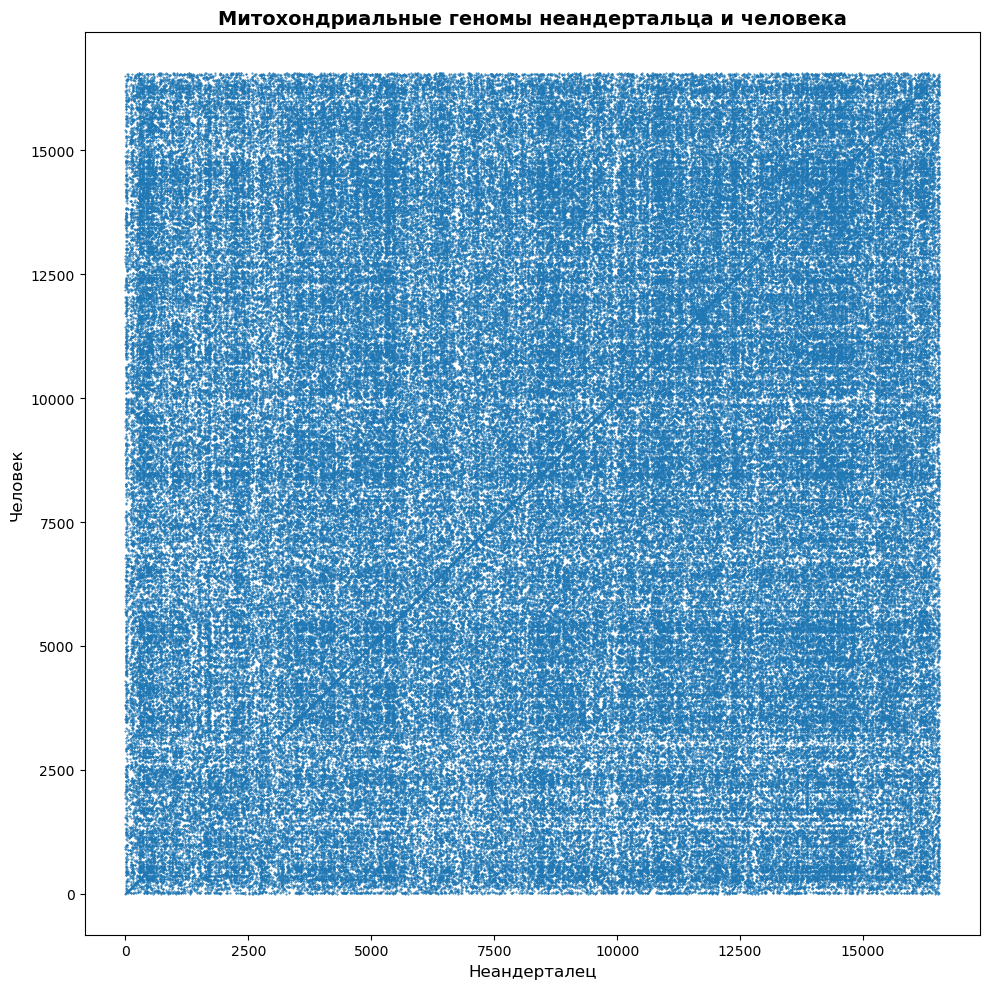

In [49]:
def dotplot(seq1, seq2, window=10, threshold=7, title1='Seq1', title2='Seq2',
            title='DotPlot', step=5):
    """
    Строит DotPlot
    - window    : длина скользящего окна
    - threshold : минимальное число совпадений в окне для постановки точки
    - step      : шаг скольжения
    """
    n1 = len(seq1)
    n2 = len(seq2)
    
    points_x = []
    points_y = []

    for i in range(0, n1 - window, step):
        for j in range(0, n2 - window, step):
            # Считаем совпадения в окне
            matches = sum(seq1[i+k] == seq2[j+k] for k in range(window))
            if matches >= threshold:
                points_x.append(i)
                points_y.append(j)
    
    # Построение графика
    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.scatter(points_x, points_y, s=0.2, rasterized=True)
    
    ax.set_xlabel(f'{title1}', fontsize=12)
    ax.set_ylabel(f'{title2}', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    
    plt.tight_layout()
    plt.show()


# Строим DotPlot
dotplot(
    seq_neandertal, seq_human,
    window=10,
    threshold=6,
    step=5,
    title1='Неандерталец',
    title2='Человек',
    title='Митохондриальные геномы неандертальца и человека'
)

1. На графике нет антидиагональных линий, т.е. нет инверсий, и нет горизонтальных/вертикальных участков (не шум а именно линий), т.е. нет крупных делеций/дупликаций. Митохондриальные геномы обоих видов сохранили одинаковую организацию.

2. Диагональ практически непрерывная, потому что геномы похожи. Видно много шума кроме диагонали, но это объяснимо т.к. геномы неандертальца и человека реально очень похожи (99% сходство), поэтому почти в любом месте генома можно найти короткий похожий фрагмент.

3. Мелкие разрывы/пропуски на диагонали соответствуют точечным заменам нуклеотидов. 